In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1

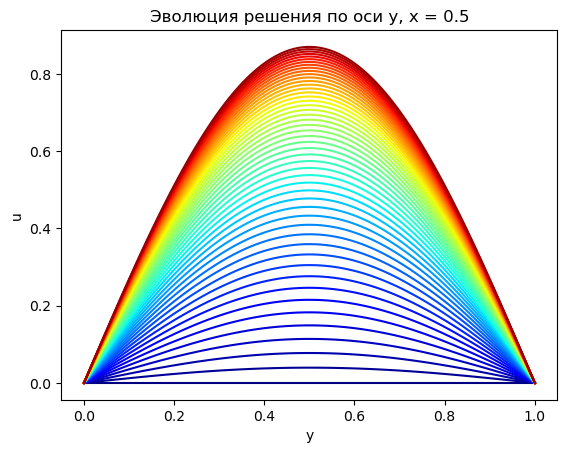

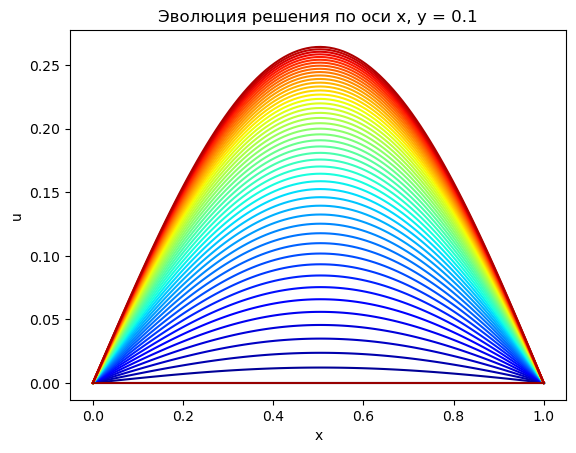

In [4]:
from matplotlib import cm
from numba import njit
from tqdm import tqdm

a = 1.0
Lx = 1.0
Ly = 1.0
T = 0.2
Nx = 100
Ny = 100
Nt = 100 
hx = Lx/(Nx-1)
hy = Ly/(Ny-1)
tau = T/(Nt-1)
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
t = np.linspace(0, T, Nt)


def u0(x, y):
    return 0
def ul(t):
    return 0
def ur(t):
    return 0
def uu(t):
    return 0
def ud(t):
    return 0
def f(t, x, y):
    return 2*np.pi**2*np.sin(np.pi*x)*np.sin(np.pi*y)

u = np.zeros((Nt, Nx, Ny))

u[0, :, :] = u0(x,y)

u[:, 0, :] = ul(t)
u[:, -1, :] = ur(t)
u[:, :, 0] = ud(t)
u[:, :, -1] = uu(t)

r = a*tau/(2*hx**2)
Ax = np.zeros((Nx, Nx))
for i in range(1, Nx-1): 
    Ax[i, i] = 1 + 2*r
    Ax[i, i-1] = -r
    Ax[i, i+1] = -r
Ax[0, 0] = 1
Ax[-1, -1] = 1

Bx = np.zeros((Nx, Nx))
for i in range(1, Nx-1):
    Bx[i, i] = 1 - 2*r
    Bx[i, i-1] = r
    Bx[i, i+1] = r

r = a*tau/(2*hy**2)
Ay = np.zeros((Ny, Ny))
for i in range(1, Ny-1): 
    Ay[i, i] = 1 + 2*r
    Ay[i, i-1] = -r
    Ay[i, i+1] = -r
Ay[0, 0] = 1
Ay[-1, -1] = 1

By = np.zeros((Ny, Ny))
for i in range(1, Ny-1):
    By[i, i] = 1 - 2*r
    By[i, i-1] = r
    By[i, i+1] = r

for n in range(1, Nt-1, 2):

    bx = np.zeros(Nx)

    bx[0] = ul(t[n])
    bx[-1] = ur(t[n])
    bx[1: -1] = 0

    by = np.zeros(Ny)


    for i in range(Ny):
      F = Bx @ u[n-1,:,i] + bx

      u[n, :, i] = np.linalg.solve(Ax, F)


    for i in range(Nx):
      by[0] = ud(t[n])
      by[-1] = uu(t[n])
      by[1: -1] = tau*f(t[n-1], i/Nx, y[1:-1])
      F = By @ u[n,i,:] + by

      u[n+1, i, :] = np.linalg.solve(Ay, F)

fig, ax = plt.subplots()
for n in range(0, Nt, 2):
    color = cm.jet(n/Nt)
    ax.plot(x, u[n, 50, :], color=color, label=f"t={t[n]:.2f}")
ax.set_xlabel("y")
ax.set_ylabel("u")
norm = plt.Normalize(0, T)
cmap = cm.jet
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.title('Эволюция решения по оси y, x = 0.5')
plt.show()

fig, ax = plt.subplots()
for n in range(0, Nt, 2):
    color = cm.jet(n/Nt)
    ax.plot(x, u[n+1, :, 10], color=color, label=f"t={t[n]:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("u")
norm = plt.Normalize(0, T)
cmap = cm.jet
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

plt.title('Эволюция решения по оси x, y = 0.1')
plt.show()

# 2

CFL = 0.240 (должно быть ≤ 0.5 для устойчивости явной схемы)


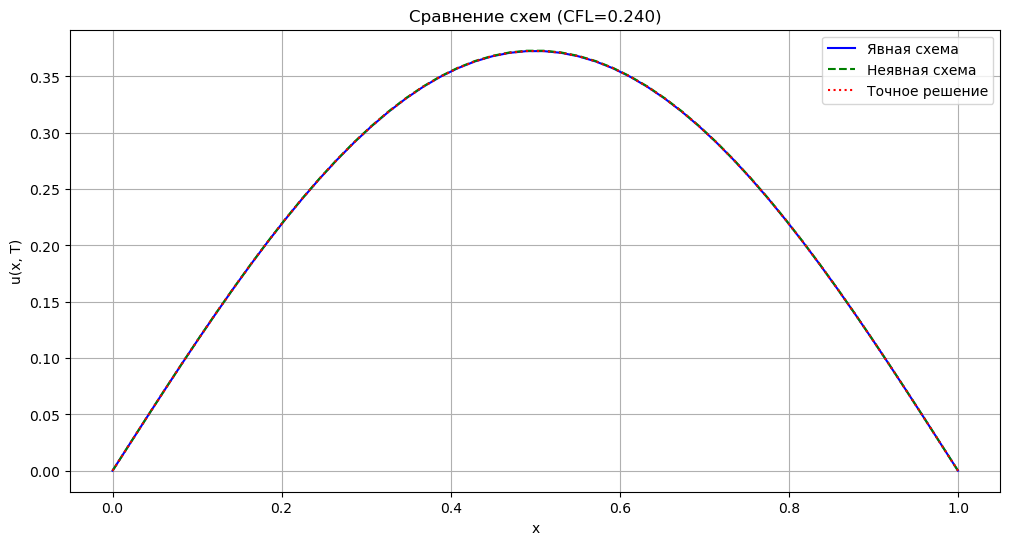

In [13]:
L = 1.0   
T = 0.1      
a = 1.0         
Nx = 50        
Nt = 1000       
h = L / (Nx-1)
tau = T / Nt

CFL = a**2 * tau / h**2
print(f"CFL = {CFL:.3f} (должно быть ≤ 0.5 для устойчивости явной схемы)")

x = np.linspace(0, L, Nx)
u_explicit = np.sin(np.pi * x)  
u_implicit = u_explicit.copy()

# Явная схема
for n in range(Nt):
    u_prev = u_explicit.copy()
    for i in range(1, Nx-1):
        u_explicit[i] = u_prev[i] + a**2 * tau / h**2 * (u_prev[i+1] - 2*u_prev[i] + u_prev[i-1])

# Неявная схема
alpha = a**2 * tau / h**2
A = np.zeros((Nx, Nx))
B = np.zeros(Nx)
for i in range(1, Nx-1):
    A[i, i-1] = -alpha
    A[i, i] = 1 + 2*alpha
    A[i, i+1] = -alpha
A[0, 0], A[-1, -1] = 1, 1

for n in range(Nt):
    B[1:-1] = u_implicit[1:-1]
    u_implicit = np.linalg.solve(A, B)

u_exact = np.exp(-np.pi**2 * T) * np.sin(np.pi * x)

plt.figure(figsize=(12, 6))
plt.plot(x, u_explicit, 'b-', label='Явная схема')
plt.plot(x, u_implicit, 'g--', label='Неявная схема')
plt.plot(x, u_exact, 'r:', label='Точное решение')
plt.xlabel('x')
plt.ylabel('u(x, T)')
plt.legend()
plt.grid(True)
plt.title(f'Сравнение схем (CFL={CFL:.3f})')
plt.show()

# 3

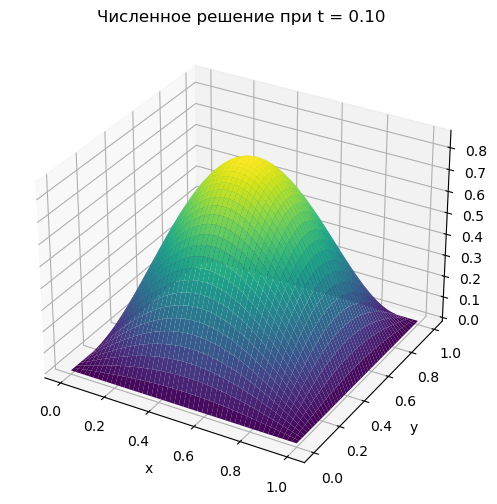

Максимальная ошибка: 2.338e-01


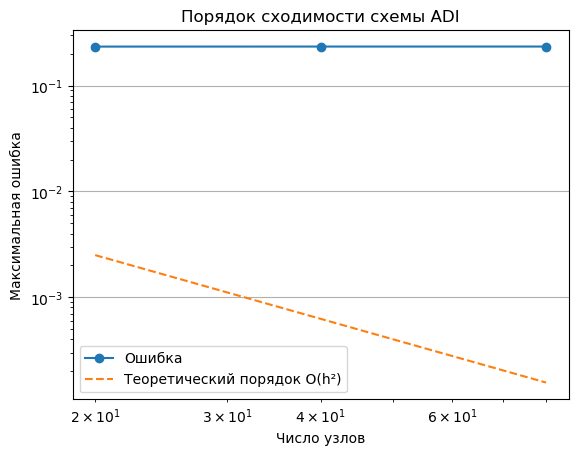

In [10]:
from mpl_toolkits.mplot3d import Axes3D

Lx, Ly = 1.0, 1.0  
T = 0.1          
Nx, Ny = 50, 50    
Nt = 100           
dx = Lx / (Nx-1)
dy = Ly / (Ny-1)
dt = T / Nt

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
t = np.linspace(0, T, Nt+1)
X, Y = np.meshgrid(x, y, indexing='ij')

u = np.zeros((Nx, Ny, Nt+1))

def exact_solution(x, y, t):
    return (1 - np.exp(-np.pi**2 * t)) * np.sin(np.pi * x) * np.sin(np.pi * y)

def f(x, y):
    return 2 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)

# ADI-схема 
for n in range(Nt):
    u_half = u[:, :, n].copy()
    alpha = dt / (2 * dx**2)
    for j in range(1, Ny-1):
        A = np.zeros((Nx, Nx))
        B = np.zeros(Nx)
        
        for i in range(1, Nx-1):
            A[i, i-1] = -alpha
            A[i, i] = 1 + 2*alpha
            A[i, i+1] = -alpha
            B[i] = u[i, j, n] + alpha * (u[i, j+1, n] - 2*u[i, j, n] + u[i, j-1, n]) + dt/2 * f(x[i], y[j])
        
        A[0, 0] = 1
        B[0] = 0
        A[-1, -1] = 1
        B[-1] = 0
        
        u_half[:, j] = np.linalg.solve(A, B)

    u_next = u_half.copy()
    beta = dt / (2 * dy**2)
    for i in range(1, Nx-1):
        A = np.zeros((Ny, Ny))
        B = np.zeros(Ny)
        
        for j in range(1, Ny-1):
            A[j, j-1] = -beta
            A[j, j] = 1 + 2*beta
            A[j, j+1] = -beta
            B[j] = u_half[i, j] + beta * (u_half[i+1, j] - 2*u_half[i, j] + u_half[i-1, j]) + dt/2 * f(x[i], y[j])
        
        A[0, 0] = 1
        B[0] = 0
        A[-1, -1] = 1
        B[-1] = 0
        
        u_next[i, :] = np.linalg.solve(A, B)
    
    u[:, :, n+1] = u_next

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, u[:, :, -1], cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Численное решение при t = %.2f' % T)
plt.show()

u_exact = exact_solution(X, Y, T)
error = np.abs(u[:, :, -1] - u_exact)
print(f"Максимальная ошибка: {np.max(error):.3e}")

def compute_error(N):
    Lx, Ly = 1.0, 1.0
    T = 0.1
    Nt = int(2 * N)  
    dx = Lx / (N-1)
    dy = Ly / (N-1)
    dt = T / Nt

    x = np.linspace(0, Lx, N)
    y = np.linspace(0, Ly, N)
    X, Y = np.meshgrid(x, y, indexing='ij')


    u = np.zeros((N, N, Nt+1))

    # ADI-схема
    for n in range(Nt):
        u_half = u[:, :, n].copy()
        alpha = dt / (2 * dx**2)
        for j in range(1, N-1):
            A = np.zeros((N, N))
            B = np.zeros(N)
            for i in range(1, N-1):
                A[i, i-1] = -alpha
                A[i, i] = 1 + 2 * alpha
                A[i, i+1] = -alpha
                B[i] = u[i, j, n] + alpha * (u[i, j+1, n] - 2*u[i, j, n] + u[i, j-1, n]) + dt/2 * f(x[i], y[j])
            A[0, 0], A[-1, -1] = 1, 1
            B[0], B[-1] = 0, 0
            u_half[:, j] = np.linalg.solve(A, B)

        u_next = u_half.copy()
        beta = dt / (2 * dy**2)
        for i in range(1, N-1):
            A = np.zeros((N, N))
            B = np.zeros(N)
            for j in range(1, N-1):
                A[j, j-1] = -beta
                A[j, j] = 1 + 2 * beta
                A[j, j+1] = -beta
                B[j] = u_half[i, j] + beta * (u_half[i+1, j] - 2*u_half[i, j] + u_half[i-1, j]) + dt/2 * f(x[i], y[j])
            A[0, 0], A[-1, -1] = 1, 1
            B[0], B[-1] = 0, 0
            u_next[i, :] = np.linalg.solve(A, B)
        
        u[:, :, n+1] = u_next

    u_exact = exact_solution(X, Y, T)
    error = np.abs(u[:, :, -1] - u_exact)
    return np.max(error)

errors = []
Ns = [20, 40, 80]
for N in Ns:
    errors.append(compute_error(N))

plt.loglog(Ns, errors, 'o-', label='Ошибка')
plt.loglog(Ns, [1/(n**2) for n in Ns], '--', label='Теоретический порядок O(h²)')
plt.xlabel('Число узлов')
plt.ylabel('Максимальная ошибка')
plt.legend()
plt.grid(True)
plt.title('Порядок сходимости схемы ADI')
plt.show()

# 4

/var/folders/pp/mwb40zv519zbg002_qh26rb40000gn/T/ipykernel_7738/1802020532.py:29: RuntimeWarning: overflow encountered in double_scalars
  term_x = u_prev[i+1,j] * (u_prev[i+1,j] - u_prev[i,j]) / hx**2 - u_prev[i,j] * (u_prev[i,j] - u_prev[i-1,j]) / hx**2
/var/folders/pp/mwb40zv519zbg002_qh26rb40000gn/T/ipykernel_7738/1802020532.py:30: RuntimeWarning: overflow encountered in double_scalars
  term_y = u_prev[i,j+1] * (u_prev[i,j+1] - u_prev[i,j]) / hy**2 - u_prev[i,j] * (u_prev[i,j] - u_prev[i,j-1]) / hy**2
/var/folders/pp/mwb40zv519zbg002_qh26rb40000gn/T/ipykernel_7738/1802020532.py:29: RuntimeWarning: invalid value encountered in double_scalars
  term_x = u_prev[i+1,j] * (u_prev[i+1,j] - u_prev[i,j]) / hx**2 - u_prev[i,j] * (u_prev[i,j] - u_prev[i-1,j]) / hx**2
/var/folders/pp/mwb40zv519zbg002_qh26rb40000gn/T/ipykernel_7738/1802020532.py:30: RuntimeWarning: invalid value encountered in double_scalars
  term_y = u_prev[i,j+1] * (u_prev[i,j+1] - u_prev[i,j]) / hy**2 - u_prev[i,j] * (u_p

Сходимость достигнута на итерации 49


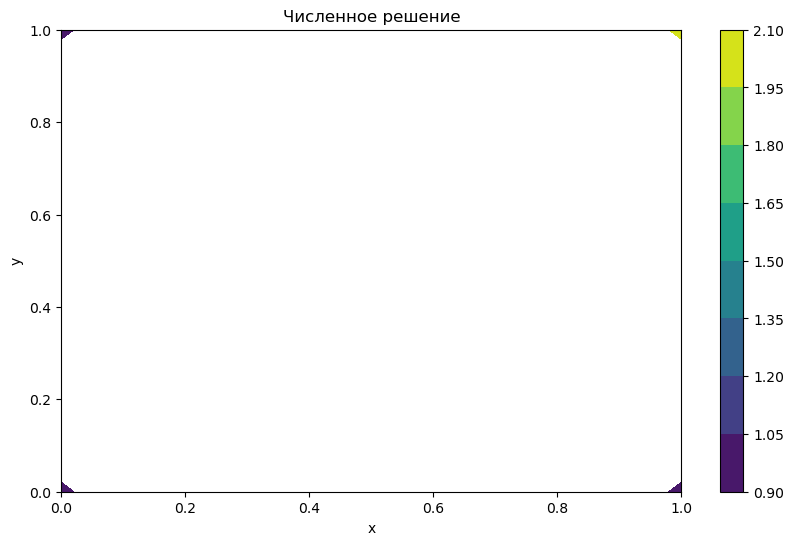

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
X, Y = 1.0, 1.0
Nx, Ny = 50, 50
hx, hy = X / (Nx-1), Y / (Ny-1)
max_iter = 1000
tolerance = 1e-6
relax = 0.1  # Параметр релаксации

# Сетка
x = np.linspace(0, X, Nx)
y = np.linspace(0, Y, Ny)
u = np.ones((Nx, Ny))

# Граничные условия
u[0, :] = 1                # u(0, y) = 1
u[:, -1] = 1 + x**2        # u(x, Y) = 1 + x²
u[-1, :] = 1 + (X**2 * y) / Y  # u(X, y) = 1 + X² y / Y
u[:, 0] = 1                # u(x, 0) = 1

# Итерации с релаксацией
for k in range(max_iter):
    u_prev = u.copy()
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            # Линеаризованные члены с использованием предыдущего приближения
            term_x = u_prev[i+1,j] * (u_prev[i+1,j] - u_prev[i,j]) / hx**2 - u_prev[i,j] * (u_prev[i,j] - u_prev[i-1,j]) / hx**2
            term_y = u_prev[i,j+1] * (u_prev[i,j+1] - u_prev[i,j]) / hy**2 - u_prev[i,j] * (u_prev[i,j] - u_prev[i,j-1]) / hy**2
            
            # Обновление с релаксацией
            delta = (term_x + term_y) * hx * hy / (hx + hy)
            u[i,j] = u_prev[i,j] - relax * delta  # Замедление изменений
    
    error = np.nanmax(np.abs(u - u_prev))
    if error < tolerance:
        print(f"Сходимость достигнута на итерации {k+1}")
        break

# Визуализация
plt.figure(figsize=(10, 6))
plt.contourf(x, y, u.T, cmap='viridis')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Численное решение')
plt.show()